In [1]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import matplotlib.pyplot as plt

import numpy as np
import ROOT

import emm
import coverage as cov

Welcome to JupyROOT 6.30/04


In [2]:
# Configuration
n_toys = 400
n_bootstraps = 1000
n_events_per_toy = 5036

# Test Config
# n_toys = 2
# n_bootstraps = 2
# n_events_per_toy = 5036

np.random.seed(42)
seeds = np.random.randint(0, 10000, size=n_toys)

n_test_points = 1000
test_range = (500, 3500)
test_points = np.linspace(test_range[0], test_range[1], n_test_points)

In [3]:
# Load the data
data_tree = emm.get_data(sort_and_index=True, tree=True)
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = data.numEntries()

Loaded 5036 diphoton invariant masses from data.


In [4]:
# Set up models
toy_models = [
    emm.f1(x, prefix="true"),
    emm.f2(x, prefix="true"),
    emm.f3(x, prefix="true"),
    emm.f4(x, prefix="true"),
]

model_primitives = [
    emm.f1,
    emm.f2,
    emm.f3,
    emm.f4,
    emm.ExponentialMixtureModel_2,
    emm.ExponentialMixtureModel_3,
    # emm.ExponentialMixtureModel_4,
]


for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(data)

true_pdf_vals = {
    toy_model.name: emm.evaluate_pdf(x, toy_model, test_points)
    for toy_model in toy_models
}

Fitting toy model: f_1
Fitting toy model: f_2
Fitting toy model: f_3
Fitting toy model: f_4
[#1] INFO:NumericIntegration -- RooRealIntegral::init(true_f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
true_p1	  = 5.71808	 +/-  0.898473	(limited)
true_p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(true_f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31033.41007
  Edm           : 0.4026341363
  Internal parameters:	[   -0.06003605845    -0.1202898824]	
  Internal gradient  :	[      -55.0368949     -36.51043855]	
  Internal covariance matrix:
[[  0.00026610788              0]
 [              0  0.00060350528]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =        31033.2098 Edm =   3.319820566e-06 NCalls =     15
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Info in <Minuit2>: VariableMetricBuilder After Hessian
I

In [ ]:
# Run jobs
cov.run_coverage_tasks(
    x, toy_models, model_primitives,
    seeds, n_bootstraps,
    n_events_per_toy, test_points,
    use_condor=True,
    # remake=True,
)

In [5]:
coverages = cov.get_coverages(
    toy_models,
    model_primitives,
    seeds,
    n_bootstraps,
    n_events_per_toy,
    true_pdf_vals,
    alpha=0.05,
)

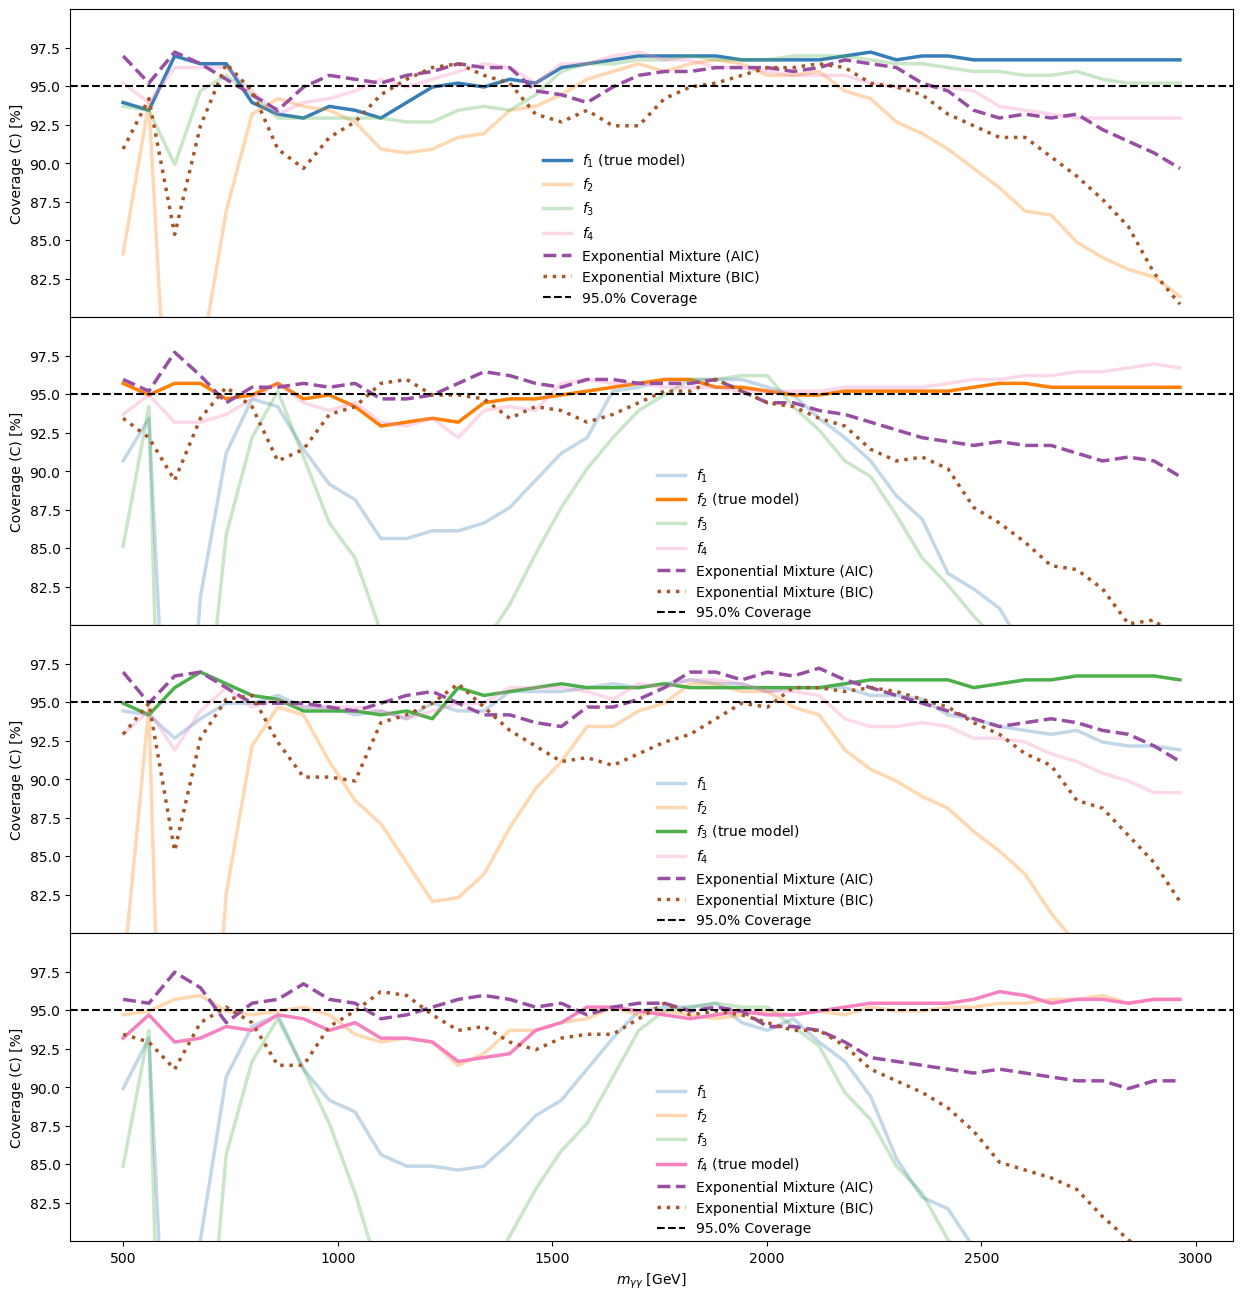

In [6]:
# Plot the results
cov.plot_coverages(coverages, test_points, alpha=0.05, y_min=0.8, range=(500,3000), skip_every=20)